In [7]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df_ledger = pd.read_excel('/content/Master_Ledger_Data.xlsx')

# Display the first 5 rows of the DataFrame
display(df_ledger.head())

,Client_ID,Client_Name,Sector,Asset_Class,Region,Outstanding_Balance_AUD,Maturity_Date,Internal_Risk_Rating,Capital_Account_Code,Is_SBTi_Aligned,EVIC_AUD,Total_Revenue_AUD,Reported_Scope_1_2_tCO2e,Intensity Factor (tCO2e per $1M Revenue),PCAF Score,Estimated_Scope_1_2_Total,Final_Data_Quality_Score
0,MAC-CGM-2000,Counterparty_000,Technology,Listed Equity,Australia,1.903974e+08,2028-06-09,8,GL-800-X,Yes,3.227814e+09,2.734773e+08,5469.55,25.0,5.0,5469.55,2.0
1,MAC-CGM-2005,Counterparty_005,Technology,Unlisted Equity,Australia,9.500336e+07,2032-06-12,1,GL-559-X,Yes,8.393137e+08,9.106179e+07,NaN,25.0,5.0,NaN,5.0
2,MAC-CGM-2001,Counterparty_001,Aviation,Corporate Loan,Americas,3.004408e+08,2032-01-09,3,GL-314-X,No,1.758942e+09,5.998740e+08,NaN,850.0,4.0,NaN,4.0
3,MAC-CGM-2002,Counterparty_002,Agricultural Commodities,Corporate Loan,Americas,3.375139e+07,2031-12-06,5,GL-199-X,No,4.244278e+07,2.177670e+07,3266.51,NaN,NaN,3266.51,2.0
4,MAC-CGM-2004,Counterparty_004,Commercial Real Estate,Unlisted Equity,EMEA,4.851054e+08,2030-03-26,6,GL-485-X,In Progress,1.739616e+10,1.252109e+09,NaN,280.0,4.0,NaN,4.0


## Inspect Missing Values




In [8]:
missing_values_count = df_ledger.isnull().sum()
missing_values_percentage = (df_ledger.isnull().sum() / len(df_ledger)) * 100

missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage': missing_values_percentage
})

missing_values_df = missing_values_df[missing_values_df['Missing Count'] > 0]

display(missing_values_df.sort_values(by='Missing Percentage', ascending=False))

,Missing Count,Missing Percentage
Reported_Scope_1_2_tCO2e,122,61.0
Estimated_Scope_1_2_Total,122,61.0
Intensity Factor (tCO2e per $1M Revenue),75,37.5
PCAF Score,75,37.5
Final_Data_Quality_Score,42,21.0


## Determine Imputation Strategy



In [9]:
print(df_ledger[[    'Reported_Scope_1_2_tCO2e',
    'Intensity Factor (tCO2e per $1M Revenue)',
    'PCAF Score',
    'Estimated_Scope_1_2_Total',
    'Final_Data_Quality_Score']].dtypes)

Reported_Scope_1_2_tCO2e                    float64
Intensity Factor (tCO2e per $1M Revenue)    float64
PCAF Score                                  float64
Estimated_Scope_1_2_Total                   float64
Final_Data_Quality_Score                    float64
dtype: object


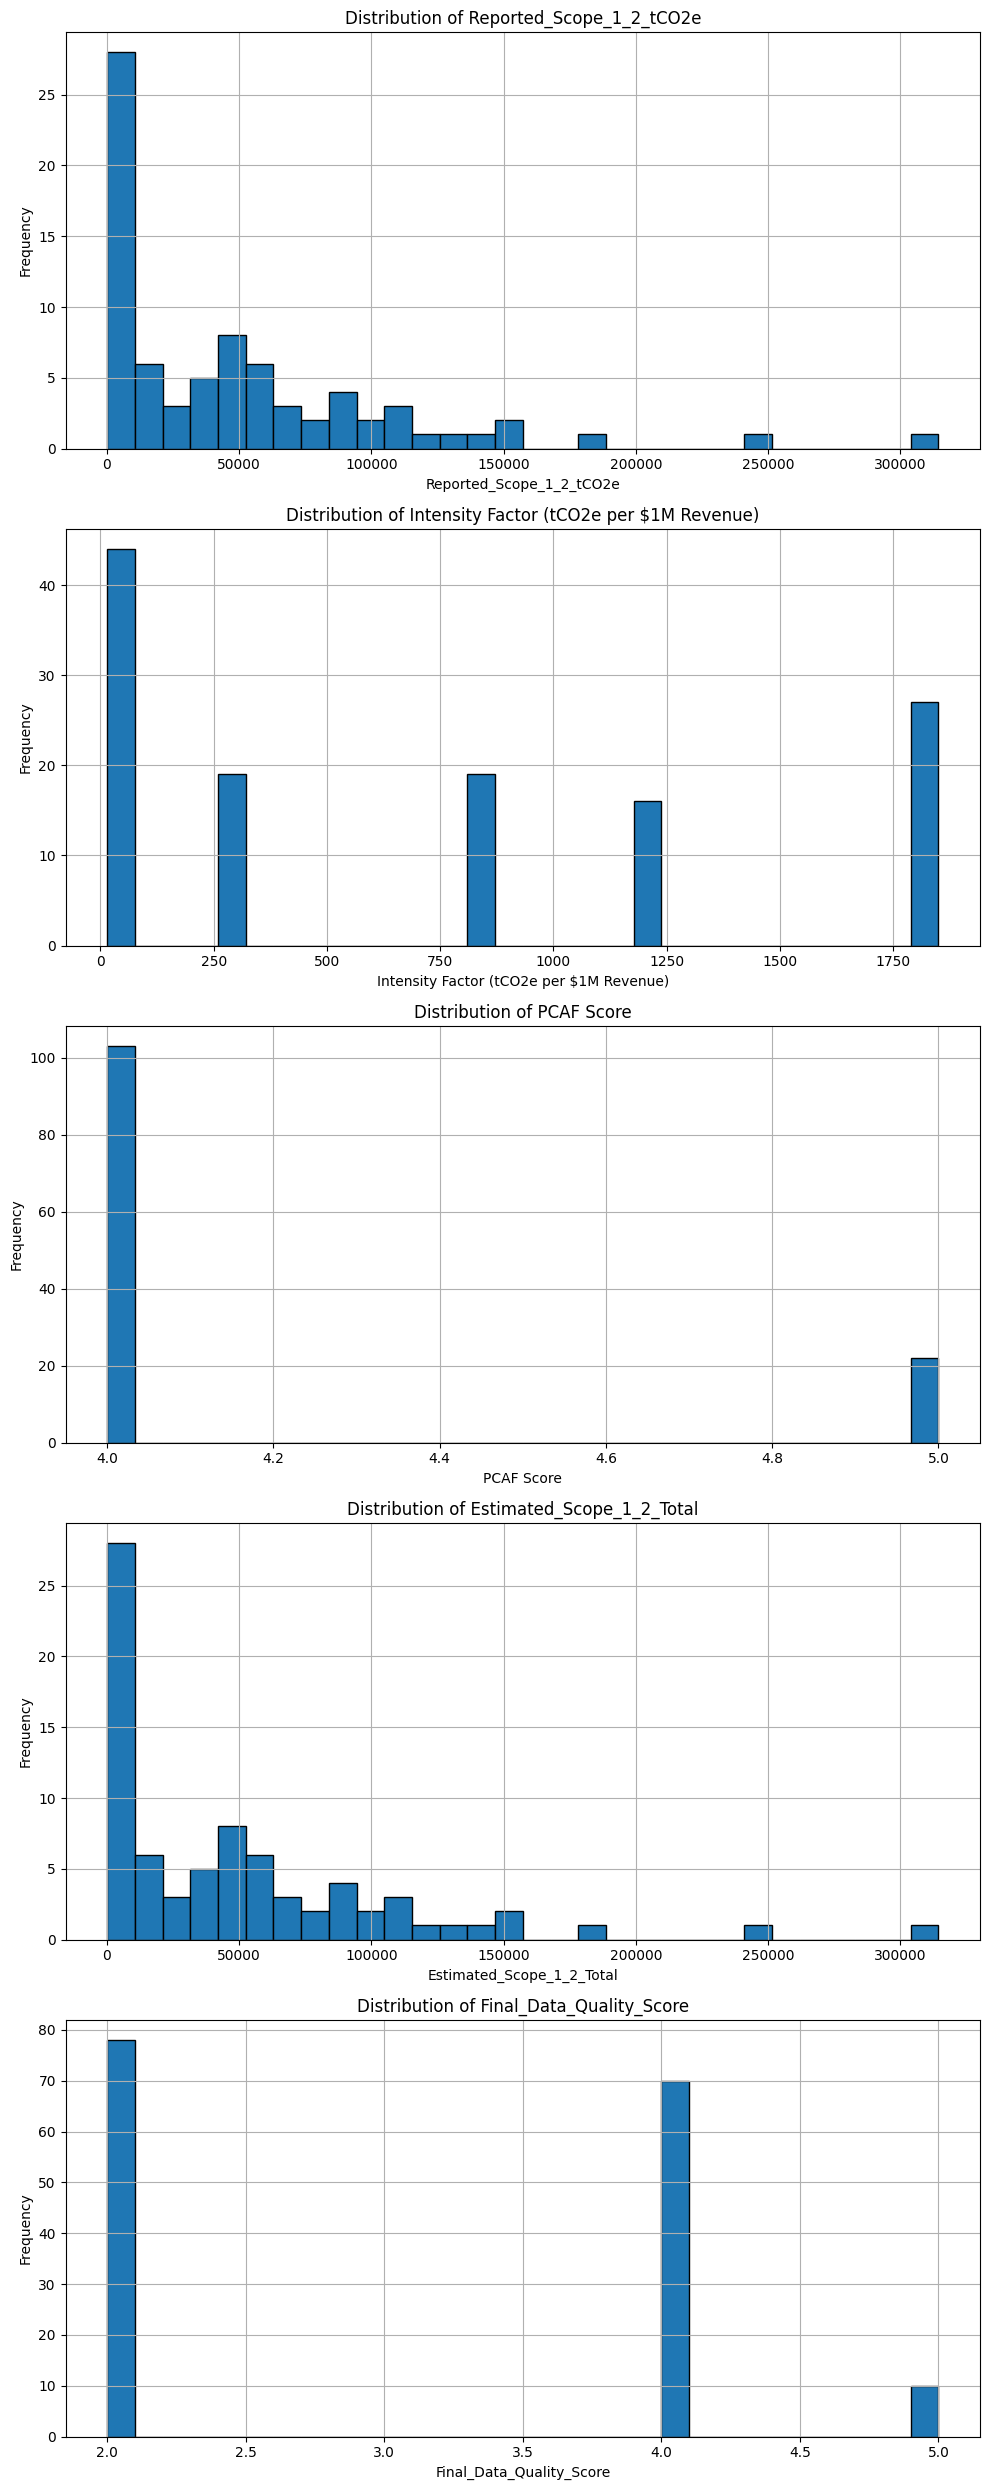


Skewness of numerical columns with missing values:
Reported_Scope_1_2_tCO2e                    2.074701
Intensity Factor (tCO2e per $1M Revenue)    0.484364
PCAF Score                                  1.722328
Estimated_Scope_1_2_Total                   2.074701
Final_Data_Quality_Score                    0.145319
dtype: float64

Proposed Imputation Strategies:
Reported_Scope_1_2_tCO2e: median
Intensity Factor (tCO2e per $1M Revenue): mean
PCAF Score: median
Estimated_Scope_1_2_Total: median
Final_Data_Quality_Score: mean


In [10]:
import matplotlib.pyplot as plt

# Columns with missing numerical values
missing_numerical_cols = [
    'Reported_Scope_1_2_tCO2e',
    'Intensity Factor (tCO2e per $1M Revenue)',
    'PCAF Score',
    'Estimated_Scope_1_2_Total',
    'Final_Data_Quality_Score'
]

# Set up the plotting area
fig, axes = plt.subplots(nrows=len(missing_numerical_cols), ncols=1, figsize=(10, 5 * len(missing_numerical_cols)))

if len(missing_numerical_cols) == 1:
    axes = [axes]

for i, col in enumerate(missing_numerical_cols):
    # Plot histogram
    df_ledger[col].hist(ax=axes[i], bins=30, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Calculate skewness for each column
skewness_values = df_ledger[missing_numerical_cols].skew()
print("\nSkewness of numerical columns with missing values:")
print(skewness_values)

# Propose imputation strategies based on skewness
imputation_strategies = {}
for col in missing_numerical_cols:
    skew = skewness_values[col]
    if abs(skew) > 1: # Highly skewed data, median is preferred
        imputation_strategies[col] = 'median'
    elif abs(skew) > 0.5: # Moderately skewed data, median might be better
        imputation_strategies[col] = 'median'
    else: # Approximately symmetric, mean is fine
        imputation_strategies[col] = 'mean'

print("\nProposed Imputation Strategies:")
for col, strategy in imputation_strategies.items():
    print(f"{col}: {strategy}")

## Apply Imputation



In [11]:
for col, strategy in imputation_strategies.items():
    if strategy == 'median':
        df_ledger[col].fillna(df_ledger[col].median(), inplace=True)
    elif strategy == 'mean':
        df_ledger[col].fillna(df_ledger[col].mean(), inplace=True)

print("Missing values after imputation:")
display(df_ledger[missing_numerical_cols].isnull().sum())

Missing values after imputation:


/tmp/ipython-input-3401374914.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ledger[col].fillna(df_ledger[col].median(), inplace=True)
/tmp/ipython-input-3401374914.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

,0
Reported_Scope_1_2_tCO2e,0
Intensity Factor (tCO2e per $1M Revenue),0
PCAF Score,0
Estimated_Scope_1_2_Total,0
Final_Data_Quality_Score,0


In [12]:
for col, strategy in imputation_strategies.items():
    if strategy == 'median':
        df_ledger[col] = df_ledger[col].fillna(df_ledger[col].median())
    elif strategy == 'mean':
        df_ledger[col] = df_ledger[col].fillna(df_ledger[col].mean())

print("Missing values after imputation:")
display(df_ledger[missing_numerical_cols].isnull().sum())

Missing values after imputation:


,0
Reported_Scope_1_2_tCO2e,0
Intensity Factor (tCO2e per $1M Revenue),0
PCAF Score,0
Estimated_Scope_1_2_Total,0
Final_Data_Quality_Score,0


## Verify Imputation




In [13]:
total_missing_after_imputation = df_ledger.isnull().sum().sum()

if total_missing_after_imputation == 0:
    print("All missing values have been successfully handled in df_ledger.")
else:
    print(f"There are still {total_missing_after_imputation} missing values in df_ledger.")

# Display missing values by column to confirm (should be all zeros)
display(df_ledger.isnull().sum()[df_ledger.isnull().sum() > 0])

All missing values have been successfully handled in df_ledger.


,0


In [14]:
df_ledger.to_csv('df_ledger_cleaned.csv', index=False)
print("df_ledger DataFrame saved to df_ledger_cleaned.csv")

df_ledger DataFrame saved to df_ledger_cleaned.csv


## Identify Columns for Advanced Imputation




In [16]:
print("Numerical columns previously identified with missing values:")
print(missing_numerical_cols)

Numerical columns previously identified with missing values:
['Reported_Scope_1_2_tCO2e', 'Intensity Factor (tCO2e per $1M Revenue)', 'PCAF Score', 'Estimated_Scope_1_2_Total', 'Final_Data_Quality_Score']


In [17]:
from sklearn.impute import KNNImputer

print("Imported KNNImputer successfully.")

Imported KNNImputer successfully.


In [18]:
import pandas as pd

# Reload the original Excel file to restore missing values for the specified columns
df_ledger = pd.read_excel('/content/Master_Ledger_Data.xlsx')

# Create an instance of KNNImputer
# n_neighbors is set to 5 by default, which is a common starting point
imputer = KNNImputer()

# Apply KNN imputation to the identified numerical columns
# We need to impute only these columns and then update them in the DataFrame
df_ledger[missing_numerical_cols] = imputer.fit_transform(df_ledger[missing_numerical_cols])

print("KNN imputation applied to the specified numerical columns.")

KNN imputation applied to the specified numerical columns.


In [19]:
print("Missing values after KNN imputation:")
display(df_ledger.isnull().sum()[df_ledger.isnull().sum() > 0])

Missing values after KNN imputation:


,0


In [25]:
df_ledger.to_csv('df_ledger_cleaned.csv', index=False)

In [26]:
import yfinance as yf
import pandas as pd

# List of real Macquarie-relevant tickers
tickers = ['BHP.AX', 'RIO.AX', 'WDS.AX', 'WBC.AX', 'TLS.AX']

def get_real_market_data(ticker_list):
    real_data = []

    for symbol in ticker_list:
        print(f"Fetching data for {symbol}...")
        ticker = yf.Ticker(symbol)
        info = ticker.info

        # PCAF requires EVIC (Enterprise Value)
        # yfinance provides 'enterpriseValue'
        evic = info.get('enterpriseValue')
        revenue = info.get('totalRevenue')
        name = info.get('longName')

        real_data.append({
            'Ticker': symbol,
            'Real_Company_Name': name,
            'EVIC_AUD': evic,
            'Total_Revenue_AUD': revenue
        })

    return pd.DataFrame(real_data)

# Execute
df_real = get_real_market_data(tickers)

# Save this to a 'Real_Market_Data.csv'
df_real.to_csv('Real_Market_Data.csv', index=False)
print("Real data saved! Now you can use this to replace rows in your ledger.")
print(df_real)

Fetching data for BHP.AX...
Fetching data for RIO.AX...
Fetching data for WDS.AX...
Fetching data for WBC.AX...
Fetching data for TLS.AX...
Real data saved! Now you can use this to replace rows in your ledger.
   Ticker            Real_Company_Name      EVIC_AUD  Total_Revenue_AUD
0  BHP.AX            BHP Group Limited  284106227712        51262001152
1  RIO.AX              Rio Tinto Group  266300309504        53729001472
2  WDS.AX    Woodside Energy Group Ltd   58851667968        13781000192
3  WBC.AX  Westpac Banking Corporation  271346958336        21959999488
4  TLS.AX        Telstra Group Limited   75599519744        23125000192


## Identify More Tickers



In [27]:
expanded_tickers = [
    'BHP.AX', 'RIO.AX', 'WDS.AX', 'WBC.AX', 'TLS.AX',
    'CBA.AX', 'NAB.AX', 'ANZ.AX', 'MQG.AX', 'FMG.AX',
    'CSL.AX', 'WOW.AX', 'TCL.AX', 'ASX.AX', 'XRO.AX'
]

print("Expanded list of tickers defined.")

Expanded list of tickers defined.


In [28]:
df_real = get_real_market_data(expanded_tickers)
print("Fetched market data for expanded tickers.")
display(df_real.head())

Fetching data for BHP.AX...
Fetching data for RIO.AX...
Fetching data for WDS.AX...
Fetching data for WBC.AX...
Fetching data for TLS.AX...
Fetching data for CBA.AX...
Fetching data for NAB.AX...
Fetching data for ANZ.AX...
Fetching data for MQG.AX...
Fetching data for FMG.AX...
Fetching data for CSL.AX...
Fetching data for WOW.AX...
Fetching data for TCL.AX...
Fetching data for ASX.AX...
Fetching data for XRO.AX...
Fetched market data for expanded tickers.


,Ticker,Real_Company_Name,EVIC_AUD,Total_Revenue_AUD
0,BHP.AX,BHP Group Limited,284106227712,51262001152
1,RIO.AX,Rio Tinto Group,266300309504,53729001472
2,WDS.AX,Woodside Energy Group Ltd,58851667968,13781000192
3,WBC.AX,Westpac Banking Corporation,271346958336,21959999488
4,TLS.AX,Telstra Group Limited,75599519744,23125000192


## Map Real Company Names to Clients




In [29]:
import itertools

# 1. Extract unique real company names from df_real
real_company_names = df_real['Real_Company_Name'].unique().tolist()
print(f"Extracted {len(real_company_names)} unique real company names.")

# 2. Identify all unique generic client names in df_ledger
generic_client_names = df_ledger[df_ledger['Client_Name'].str.startswith('Counterparty_')]['Client_Name'].unique().tolist()
print(f"Identified {len(generic_client_names)} unique generic client names.")

# 3. Create a cyclical iterator for real company names
real_name_cycler = itertools.cycle(real_company_names)

# 4. Create a mapping dictionary
client_name_mapping = {}
for generic_name in generic_client_names:
    client_name_mapping[generic_name] = next(real_name_cycler)

print("Created mapping dictionary from generic to real company names.")


Extracted 15 unique real company names.
Identified 200 unique generic client names.
Created mapping dictionary from generic to real company names.


In [30]:
df_ledger['Client_Name'] = df_ledger['Client_Name'].replace(client_name_mapping)

print("df_ledger updated with real company names. Displaying first 5 rows:")
display(df_ledger.head())

# Save the updated df_ledger to df_ledger_cleaned.csv
df_ledger.to_csv('df_ledger_cleaned.csv', index=False)
print("Updated df_ledger saved to df_ledger_cleaned.csv")

df_ledger updated with real company names. Displaying first 5 rows:


,Client_ID,Client_Name,Sector,Asset_Class,Region,Outstanding_Balance_AUD,Maturity_Date,Internal_Risk_Rating,Capital_Account_Code,Is_SBTi_Aligned,EVIC_AUD,Total_Revenue_AUD,Reported_Scope_1_2_tCO2e,Intensity Factor (tCO2e per $1M Revenue),PCAF Score,Estimated_Scope_1_2_Total,Final_Data_Quality_Score
0,MAC-CGM-2000,BHP Group Limited,Technology,Listed Equity,Australia,1.903974e+08,2028-06-09,8,GL-800-X,Yes,3.227814e+09,2.734773e+08,5469.550,25.0,5.0,5469.550,2.0
1,MAC-CGM-2005,Rio Tinto Group,Technology,Unlisted Equity,Australia,9.500336e+07,2032-06-12,1,GL-559-X,Yes,8.393137e+08,9.106179e+07,4461.590,25.0,5.0,4461.590,5.0
2,MAC-CGM-2001,Woodside Energy Group Ltd,Aviation,Corporate Loan,Americas,3.004408e+08,2032-01-09,3,GL-314-X,No,1.758942e+09,5.998740e+08,31523.906,850.0,4.0,31523.906,4.0
3,MAC-CGM-2002,Westpac Banking Corporation,Agricultural Commodities,Corporate Loan,Americas,3.375139e+07,2031-12-06,5,GL-199-X,No,4.244278e+07,2.177670e+07,3266.510,1136.0,4.0,3266.510,2.0
4,MAC-CGM-2004,Telstra Group Limited,Commercial Real Estate,Unlisted Equity,EMEA,4.851054e+08,2030-03-26,6,GL-485-X,In Progress,1.739616e+10,1.252109e+09,50059.562,280.0,4.0,50059.562,4.0


Updated df_ledger saved to df_ledger_cleaned.csv
